# Credit Pricing under Merton's 1974 Structural Framework

Compare equity and debt pricing across four models — **Black-Scholes (BSM)**, **Heston**, **Merton-Jump**, and **Kou-Jump** — using Merton's 1974 structural credit-risk framework.

**Framework**

- Asset value: $A_0 = N \cdot S_0 + D$ (shares outstanding times spot, plus face value of debt)
- Default trigger / strike: $K = D$
- Equity value: $E_0 = \mathrm{Call}(A_0, K, T, r, \sigma)$
- Debt value: $B_0 = K e^{-rT} - \mathrm{Put}(A_0, K, T, r, \sigma)$

**Tickers**

- Investment grade: AAPL, TSLA, ORCL
- Distressed / junk: GME, DISH, AMC
- Pre-collapse historical snapshot: CS (Credit Suisse before March 2023)

Helper modules used:

- `market_data_loader.py` — generalised data loaders (spot, balance sheet, IV, risk-free rate)
- `credit_pricing_models.py` — unified pricing wrappers around BSM / Heston / Merton-Jump / Kou-Jump

## 1. Setup

Load helper modules, define the ticker universe and the maturities used throughout this study.

In [1]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data_loader import (
    DEFAULT_RISK_FREE_DATE,
    MertonInputs,
    compute_merton_inputs,
    compute_merton_inputs_batch,
    historical_spot_from_yfinance,
    load_balance_sheet,
    load_risk_free_rate,
)
from credit_pricing_models import (
    DEFAULT_MATURITIES,
    HestonParams,
    KouJumpParams,
    MertonJumpParams,
    ModelParamSet,
    credit_spread_table,
    price_all_tickers,
    to_wide_table,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.dpi"] = 110

In [2]:
INVESTMENT_GRADE_TICKERS = ["AAPL", "TSLA", "ORCL"]
# Using GME and AMC as distressed (high volatility, high leverage).
# DISH and CS are delisted in yfinance, so we use BBBY (Bed Bath & Beyond, Chapter 11) instead.
DISTRESSED_TICKERS = ["GME", "AMC", "BBBY"]
# Note: Credit Suisse (CS) was acquired by UBS on 2023-03-19.
# Historical snapshot would require hand-coded balance sheet from pre-collapse period.
# HISTORICAL_TICKERS = ["CS"]
HISTORICAL_TICKERS = []  # Skip CS due to yfinance limitations

ALL_TICKERS = INVESTMENT_GRADE_TICKERS + DISTRESSED_TICKERS + HISTORICAL_TICKERS

MATURITIES = list(DEFAULT_MATURITIES)

PARAM_SET = ModelParamSet(
    heston=HestonParams(v0=0.04, kappa=2.0, theta=0.04, xi=0.30, rho=-0.7,
                        n_paths=20_000, n_steps_per_year=252, seed=42),
    merton_jump=MertonJumpParams(Lambda=1.0, muJ=-0.05, sigmaJ=0.10, n_terms=50),
    kou_jump=KouJumpParams(lam=2.0, p=0.4, eta1=10.0, eta2=5.0, u_max=200.0),
)

print(f"Tickers: {ALL_TICKERS}")
print(f"Maturities (years): {MATURITIES}")
print(f"Risk-free reference date: {DEFAULT_RISK_FREE_DATE}")

Tickers: ['AAPL', 'TSLA', 'ORCL', 'GME', 'AMC', 'BBBY']
Maturities (years): [1, 3, 5]
Risk-free reference date: 2025-12-31


## 2. Data Collection

Load Merton inputs (asset value, debt face value, ATM IV, risk-free rate) for every ticker.

**Tickers:**
- **Investment grade** (low leverage, liquid): AAPL, TSLA, ORCL
- **Distressed** (high leverage, volatile): GME, AMC, BBBY

The loaders use local CSV snapshots when available (from 2025-12-31), falling back to `yfinance` for real-time data. DISH and Credit Suisse are delisted in yfinance and thus excluded.

In [3]:
# Data source: market_data_loader functions handle both local CSVs and yfinance fallback.
# Investment-grade tickers (AAPL, TSLA, ORCL) typically have CSV snapshots from 2025-12-31.
# Distressed tickers (GME, AMC, BBBY) use yfinance fallback.

standard_tickers = INVESTMENT_GRADE_TICKERS + DISTRESSED_TICKERS
inputs_by_ticker: dict[str, MertonInputs] = compute_merton_inputs_batch(
    standard_tickers,
    ref_date=DEFAULT_RISK_FREE_DATE,
    skip_on_error=True,
)

inputs_summary = pd.DataFrame([
    inp.as_dict() for inp in inputs_by_ticker.values()
])
print(f"Successfully loaded {len(inputs_by_ticker)} / {len(standard_tickers)} tickers.")
inputs_summary

Successfully loaded 6 / 6 tickers.


,ticker,spot,shares_outstanding,total_debt,sigma,risk_free_rate,asset_value,ref_date
0,AAPL,272.8247,"14,773,260,000.0000","98,657,000,000.0000",0.5254,0.0367,"4,129,167,331,396.4844",2025-12-31
1,TSLA,438.0700,"3,751,000,000.0000","14,719,000,000.0000",0.4052,0.0367,"1,657,919,597,473.1445",2025-12-31
2,ORCL,194.5147,"2,807,000,000.0000","104,104,000,000.0000",0.5765,0.0367,"650,106,660,995.4834",2025-12-31
3,GME,20.6200,"448,300,000.0000","4,361,900,000.0000",0.9414,0.0367,"13,605,846,376.2283",2025-12-31
4,AMC,1.6100,"512,943,561.0000","8,136,000,000.0000",0.8125,0.0367,"8,961,839,140.5477",2025-12-31
5,BBBY,5.9100,"68,863,142.0000","22,071,000.0000",0.7148,0.0367,"429,052,158.7123",2025-12-31


## 3. Pricing under all four models

For every ticker we price equity and debt under BSM, Heston, Merton-Jump and Kou-Jump for maturities of 1, 3 and 5 years.

In [4]:
long_prices = price_all_tickers(
    inputs_by_ticker,
    maturities=MATURITIES,
    param_set=PARAM_SET,
)
long_prices

,ticker,model,equity_1y,debt_1y,equity_3y,debt_3y,equity_5y,debt_5y
0,AAPL,BSM,"4,034,065,408,613.6919","95,101,922,782.7926","4,040,797,151,475.5942","88,370,179,920.8900","4,047,115,490,909.1011","82,051,840,487.3833"
1,AAPL,Heston,"4,020,010,917,617.4453","95,101,922,782.8078","4,011,156,187,418.0513","88,360,712,393.0282","4,020,332,800,226.7573","81,914,134,884.6517"
2,AAPL,Merton-Jump,"4,034,065,408,613.8457","95,101,922,782.6387","4,040,798,016,256.1343","88,369,315,140.3501","4,047,139,340,038.3462","82,027,991,358.1382"
3,AAPL,Kou-Jump,"4,034,065,547,966.1270","95,101,783,430.3576","4,040,851,897,863.4116","88,315,433,533.0728","4,047,611,029,497.0146","81,556,301,899.4699"
4,TSLA,BSM,"1,643,730,992,493.8713","14,188,604,979.2731","1,644,735,133,348.0901","13,184,464,125.0542","1,645,668,210,830.8608","12,251,386,642.2839"
5,TSLA,Heston,"1,640,442,101,256.6389","14,188,604,979.2731","1,637,188,960,073.0371","13,184,464,125.0926","1,637,450,981,656.7251","12,251,387,258.9861"
6,TSLA,Merton-Jump,"1,643,730,992,493.8713","14,188,604,979.2732","1,644,735,133,348.6111","13,184,464,124.5334","1,645,668,212,680.5298","12,251,384,792.6147"
7,TSLA,Kou-Jump,"1,643,730,990,084.3481","14,188,607,388.7963","1,644,735,220,121.8889","13,184,377,351.2557","1,645,670,155,571.0422","12,249,441,902.1023"
8,ORCL,BSM,"549,776,612,312.1794","100,330,048,683.3040","559,051,195,041.2858","91,055,465,954.1976","570,118,615,258.5204","79,988,045,736.9629"
9,ORCL,Heston,"547,207,825,926.1992","100,241,020,503.2822","554,367,006,853.0691","90,319,270,878.6311","566,793,598,719.6389","79,123,900,490.8431"


## 4. Comparison tables

A wide-format pivot makes it easy to scan equity / debt prices side-by-side across the four models.

In [5]:
wide_prices = to_wide_table(long_prices, maturities=MATURITIES)

equity_cols = ["ticker"] + [c for c in wide_prices.columns if c.startswith("equity_")]
debt_cols = ["ticker"] + [c for c in wide_prices.columns if c.startswith("debt_")]

equity_table = wide_prices[equity_cols]
debt_table = wide_prices[debt_cols]
equity_table

,ticker,equity_1y_BSM,equity_1y_Heston,equity_1y_Kou-Jump,equity_1y_Merton-Jump,equity_3y_BSM,equity_3y_Heston,equity_3y_Kou-Jump,equity_3y_Merton-Jump,equity_5y_BSM,equity_5y_Heston,equity_5y_Kou-Jump,equity_5y_Merton-Jump
0,AAPL,"4,034,065,408,613.6919","4,020,010,917,617.4453","4,034,065,547,966.1270","4,034,065,408,613.8457","4,040,797,151,475.5942","4,011,156,187,418.0513","4,040,851,897,863.4116","4,040,798,016,256.1343","4,047,115,490,909.1011","4,020,332,800,226.7573","4,047,611,029,497.0146","4,047,139,340,038.3462"
1,AMC,"3,243,605,955.2843","3,137,032,034.3110","3,406,228,976.9116","3,265,547,751.8360","5,086,707,258.9321","4,909,611,174.2922","5,317,635,913.2584","5,117,775,475.6876","6,145,345,314.0687","6,188,870,789.3335","6,386,637,515.2867","6,178,036,777.1454"
2,BBBY,"407,776,665.2200","405,141,053.5320","407,780,437.3949","407,776,730.5616","409,486,087.1210","404,744,896.0650","409,732,893.0610","409,508,135.3704","411,695,907.0096","411,396,547.3517","412,361,933.4548","411,768,120.0196"
3,GME,"9,737,031,752.3268","9,626,564,872.9444","9,806,783,306.0526","9,745,200,574.6912","10,954,802,464.8690","10,755,333,538.7491","11,087,927,011.5307","10,971,872,422.4367","11,755,757,148.3067","12,414,033,853.4878","11,897,161,762.9972","11,774,328,842.7074"
4,ORCL,"549,776,612,312.1794","547,207,825,926.1992","549,992,880,710.1434","549,784,190,710.7618","559,051,195,041.2858","554,367,006,853.0691","561,641,188,512.4183","559,307,315,419.8643","570,118,615,258.5204","566,793,598,719.6389","574,894,882,116.8523","570,665,495,658.6370"
5,TSLA,"1,643,730,992,493.8713","1,640,442,101,256.6389","1,643,730,990,084.3481","1,643,730,992,493.8713","1,644,735,133,348.0901","1,637,188,960,073.0371","1,644,735,220,121.8889","1,644,735,133,348.6111","1,645,668,210,830.8608","1,637,450,981,656.7251","1,645,670,155,571.0422","1,645,668,212,680.5298"


In [6]:
debt_table

,ticker,debt_1y_BSM,debt_1y_Heston,debt_1y_Kou-Jump,debt_1y_Merton-Jump,debt_3y_BSM,debt_3y_Heston,debt_3y_Kou-Jump,debt_3y_Merton-Jump,debt_5y_BSM,debt_5y_Heston,debt_5y_Kou-Jump,debt_5y_Merton-Jump
0,AAPL,"95,101,922,782.7926","95,101,922,782.8078","95,101,783,430.3576","95,101,922,782.6387","88,370,179,920.8900","88,360,712,393.0282","88,315,433,533.0728","88,369,315,140.3501","82,051,840,487.3833","81,914,134,884.6517","81,556,301,899.4699","82,027,991,358.1382"
1,AMC,"5,718,233,185.2634","5,755,329,283.3589","5,555,610,163.6361","5,696,291,388.7118","3,875,131,881.6156","3,935,831,811.2231","3,644,203,227.2893","3,844,063,664.8601","2,816,493,826.4791","2,873,249,211.9207","2,575,201,625.2611","2,783,802,363.4023"
2,BBBY,"21,275,493.4923","21,273,181.5408","21,271,721.3174","21,275,428.1507","19,566,071.5913","19,458,832.9921","19,319,265.6513","19,544,023.3419","17,356,251.7027","17,165,897.6393","16,690,225.2575","17,284,038.6927"
3,GME,"3,868,814,623.9015","3,843,350,386.8500","3,799,063,070.1757","3,860,645,801.5372","2,651,043,911.3593","2,656,195,390.3642","2,517,919,364.6976","2,633,973,953.7917","1,850,089,227.9216","1,865,549,948.1744","1,708,684,613.2311","1,831,517,533.5209"
4,ORCL,"100,330,048,683.3040","100,241,020,503.2822","100,113,780,285.3399","100,322,470,284.7216","91,055,465,954.1976","90,319,270,878.6311","88,465,472,483.0651","90,799,345,575.6191","79,988,045,736.9629","79,123,900,490.8431","75,211,778,878.6311","79,441,165,336.8464"
5,TSLA,"14,188,604,979.2731","14,188,604,979.2731","14,188,607,388.7963","14,188,604,979.2732","13,184,464,125.0542","13,184,464,125.0926","13,184,377,351.2557","13,184,464,124.5334","12,251,386,642.2839","12,251,387,258.9861","12,249,441,902.1023","12,251,384,792.6147"


## 5. Plot type 1 — same ticker, four models

For each ticker, plot equity and debt term structure (1y/3y/5y) under all four models on a single chart. This mirrors the comparison style used in `pricing.ipynb` but extends the family to BSM/Heston/Merton-Jump/Kou-Jump.

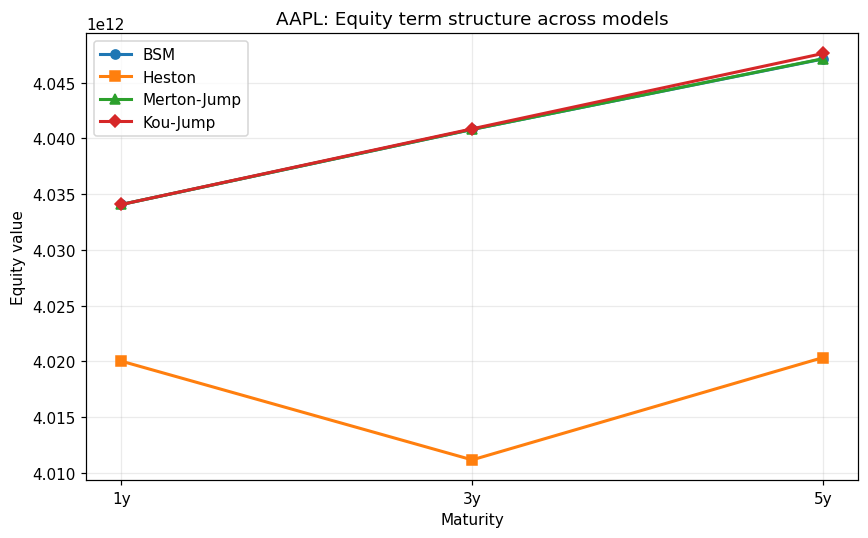

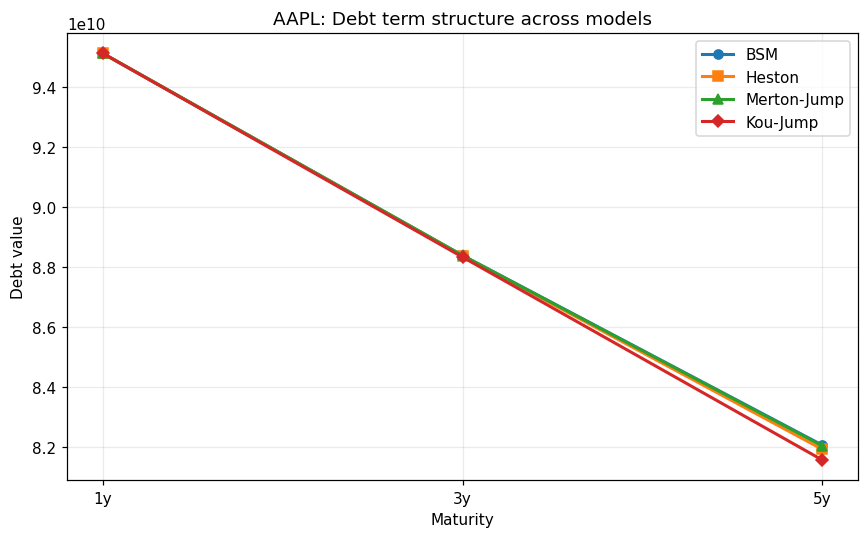

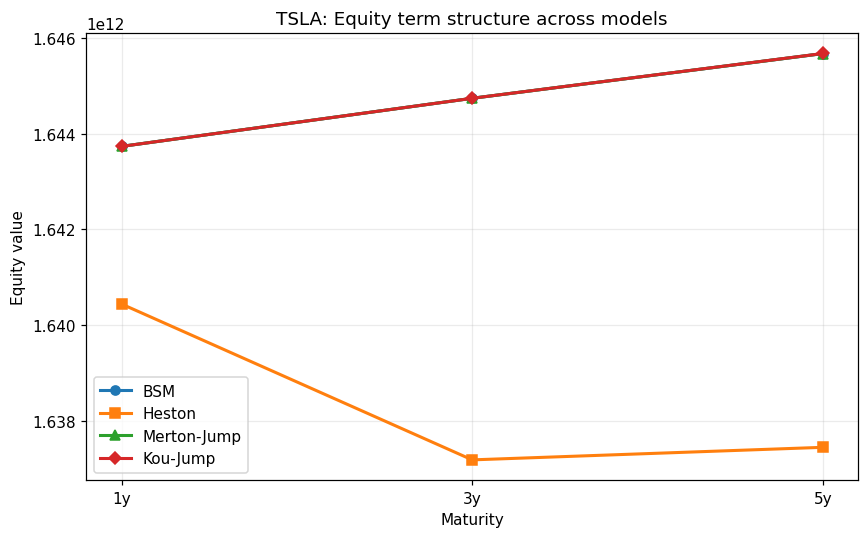

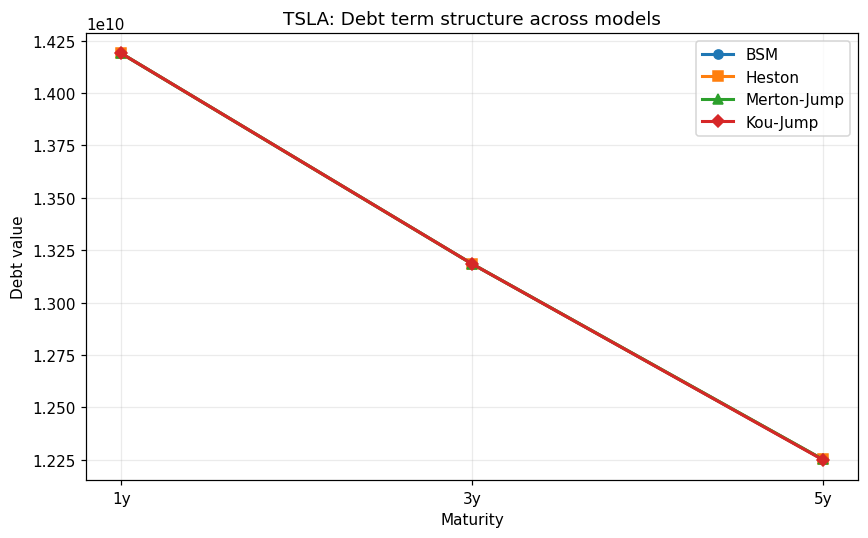

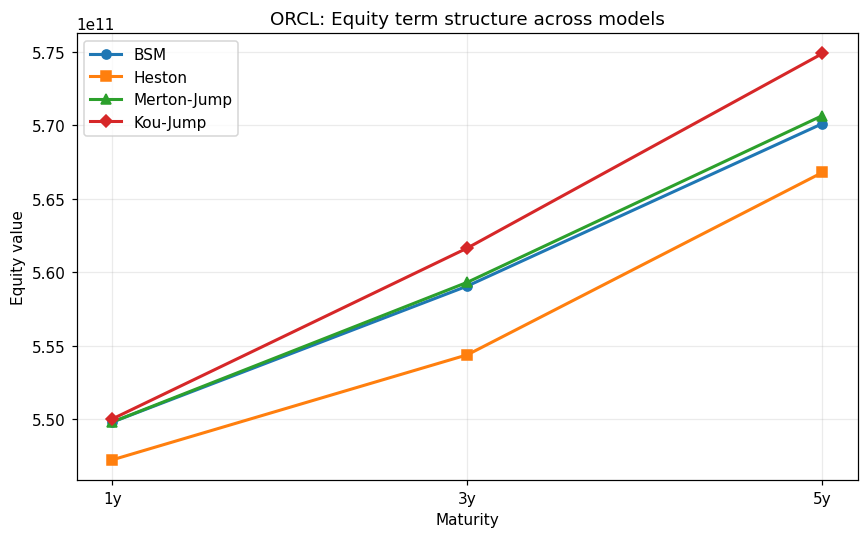

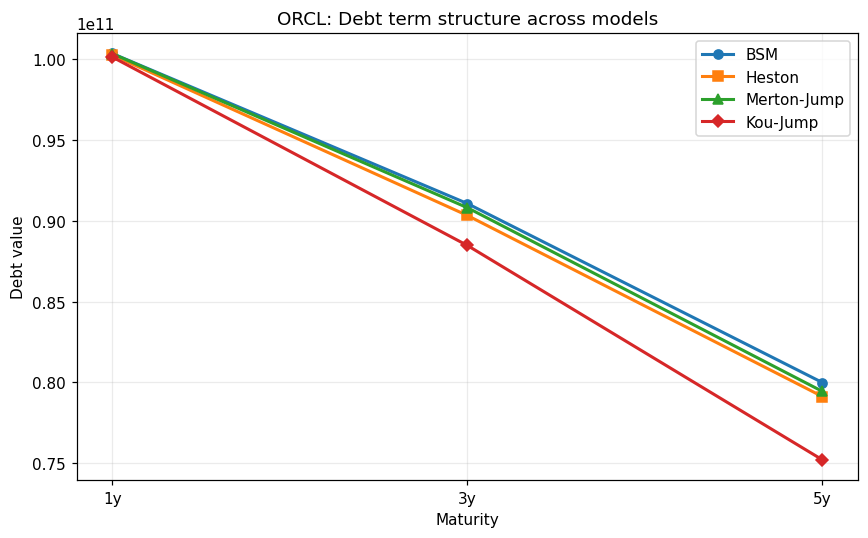

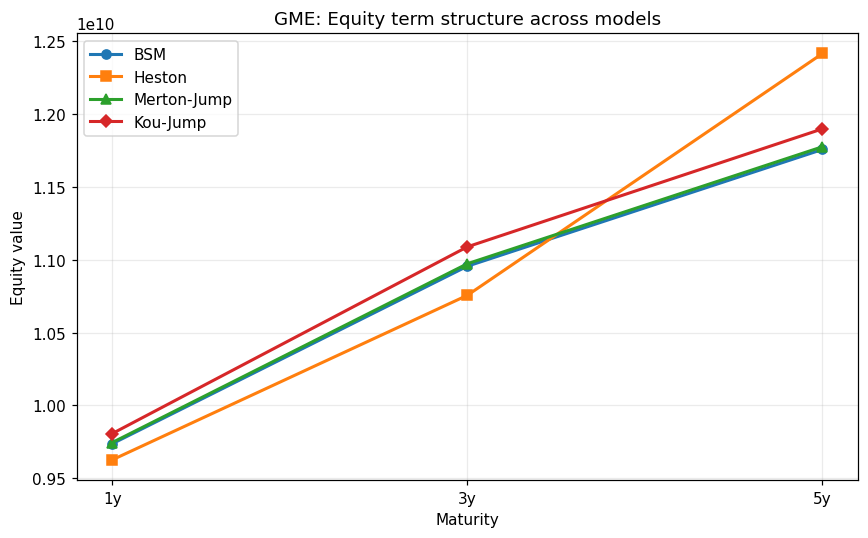

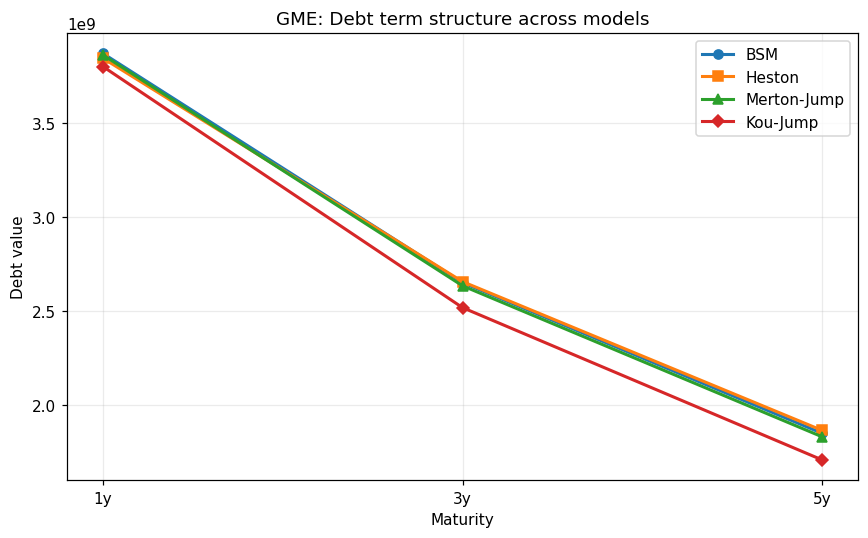

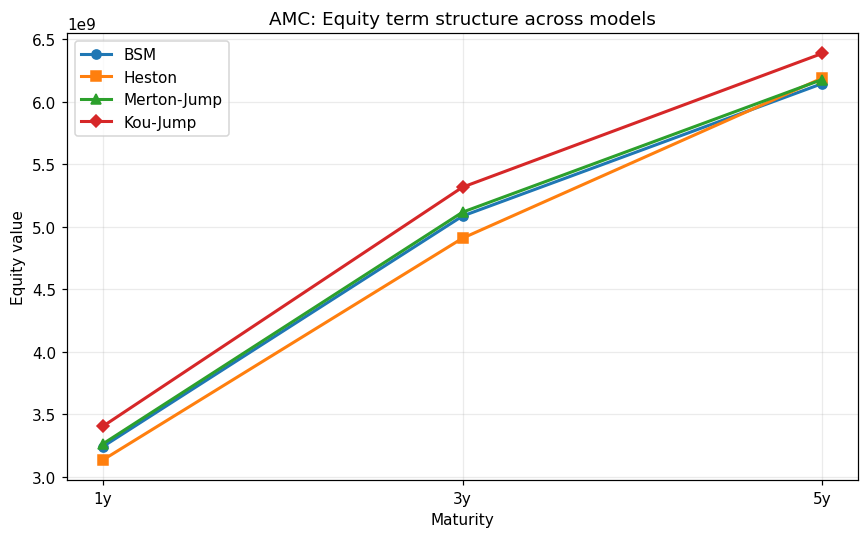

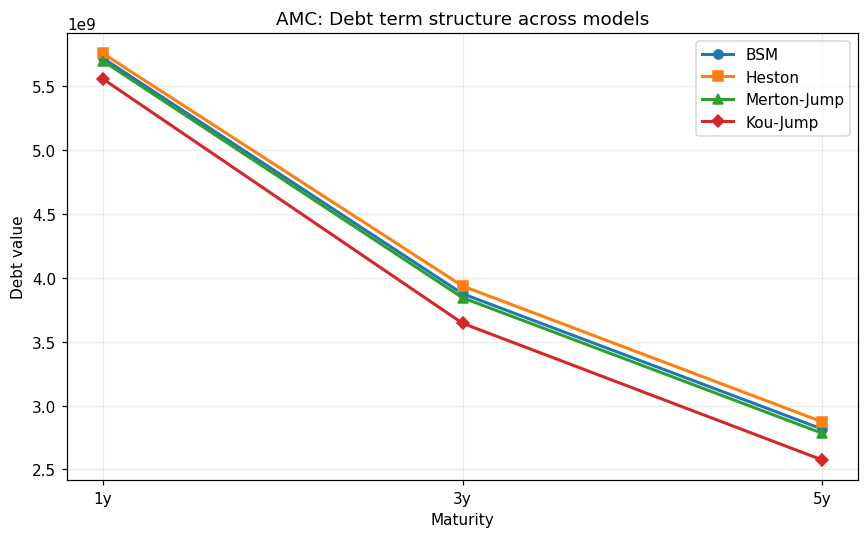

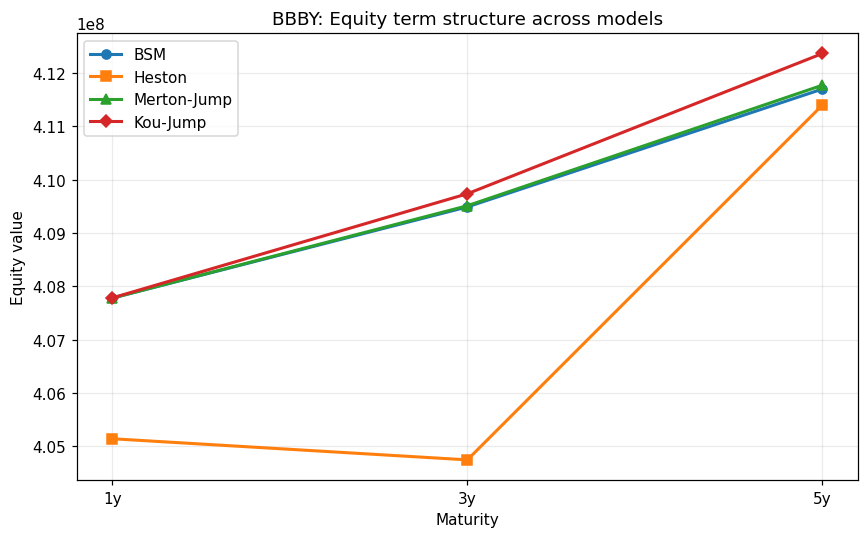

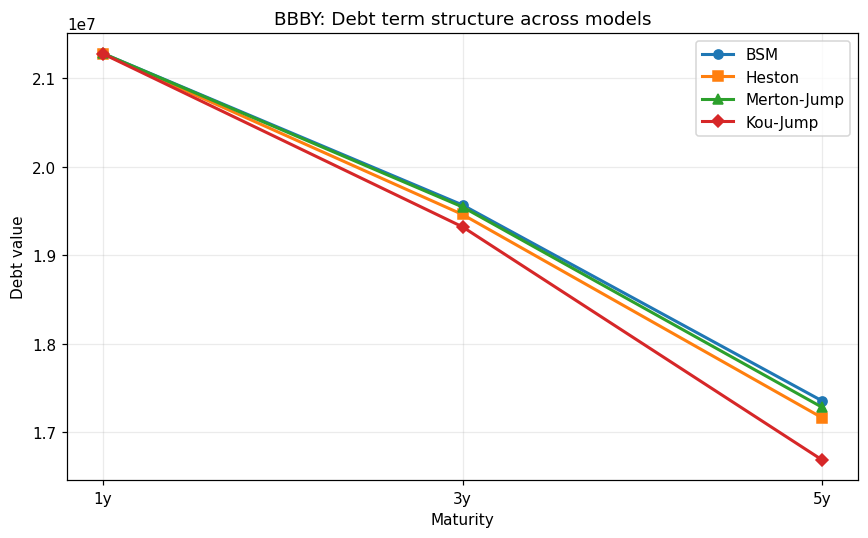

In [7]:
MATURITY_LABELS = [f"{T}y" for T in MATURITIES]
MODEL_STYLE = {
    "BSM":         {"marker": "o", "linewidth": 2},
    "Heston":      {"marker": "s", "linewidth": 2},
    "Merton-Jump": {"marker": "^", "linewidth": 2},
    "Kou-Jump":    {"marker": "D", "linewidth": 2},
}


def _plot_models_for_ticker(ticker: str, side: str) -> None:
    """side in {'equity', 'debt'} — plot all four models across maturities."""
    ticker_df = long_prices.loc[long_prices["ticker"] == ticker]
    if ticker_df.empty:
        return
    plt.figure(figsize=(8, 5))
    for model, style in MODEL_STYLE.items():
        row = ticker_df.loc[ticker_df["model"] == model]
        if row.empty:
            continue
        values = [float(row[f"{side}_{T}y"].iloc[0]) for T in MATURITIES]
        plt.plot(MATURITY_LABELS, values, label=model, **style)
    plt.title(f"{ticker}: {side.capitalize()} term structure across models")
    plt.xlabel("Maturity")
    plt.ylabel(f"{side.capitalize()} value")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


for ticker in inputs_by_ticker.keys():
    _plot_models_for_ticker(ticker, "equity")
    _plot_models_for_ticker(ticker, "debt")

## 6. Plot type 2 — multiple tickers, one model

For each non-BSM model (Heston, Merton-Jump, Kou-Jump) we overlay all tickers on the same equity term-structure plot, and likewise for debt. Because absolute scales differ wildly (Apple's asset value dwarfs GME's), we normalise each ticker to its own 1-year value so the term-structure shape is visible.

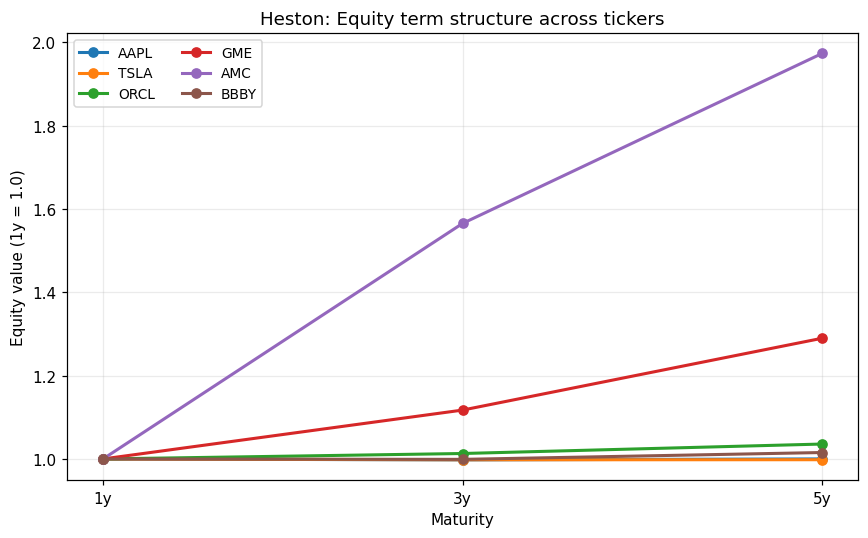

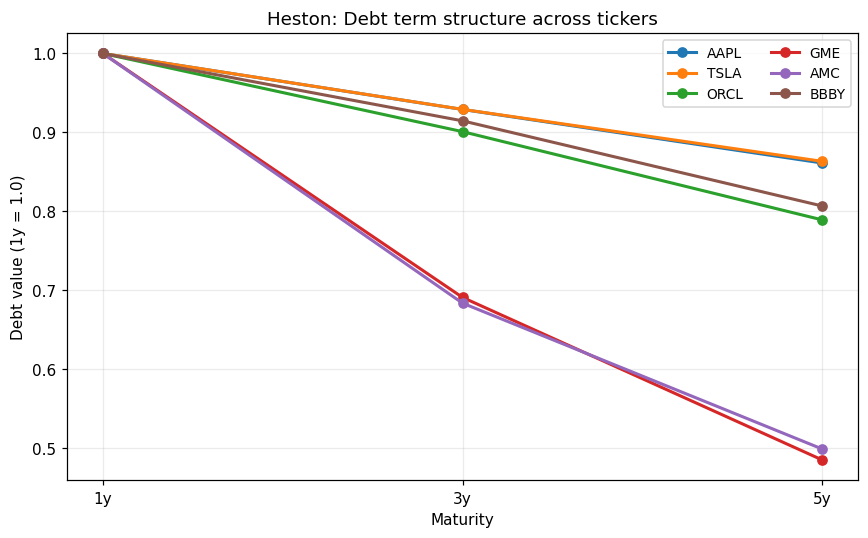

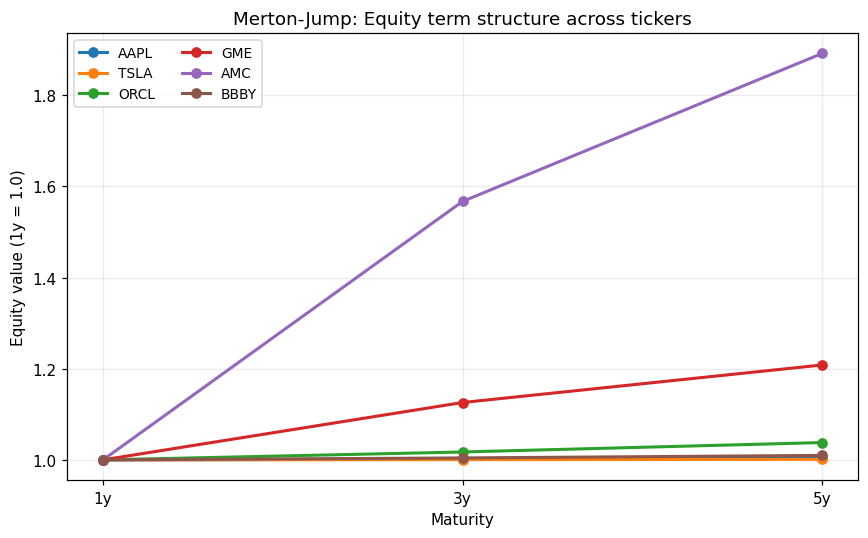

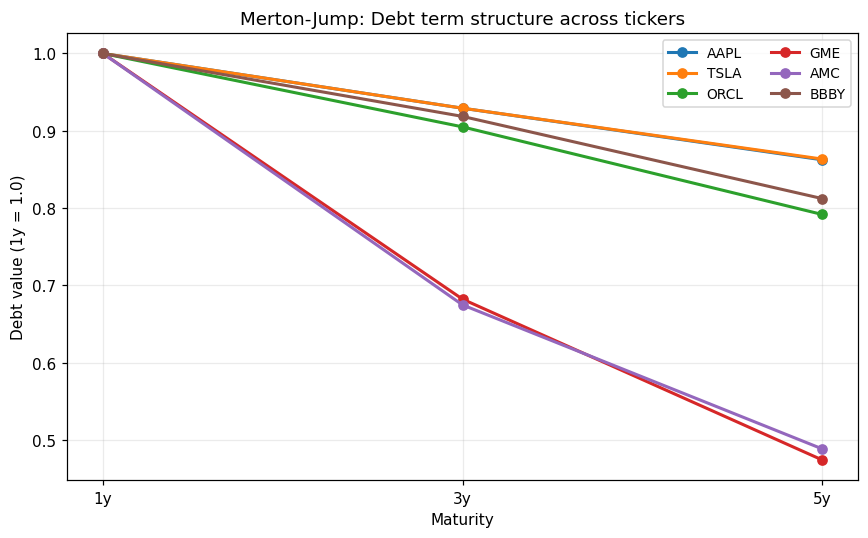

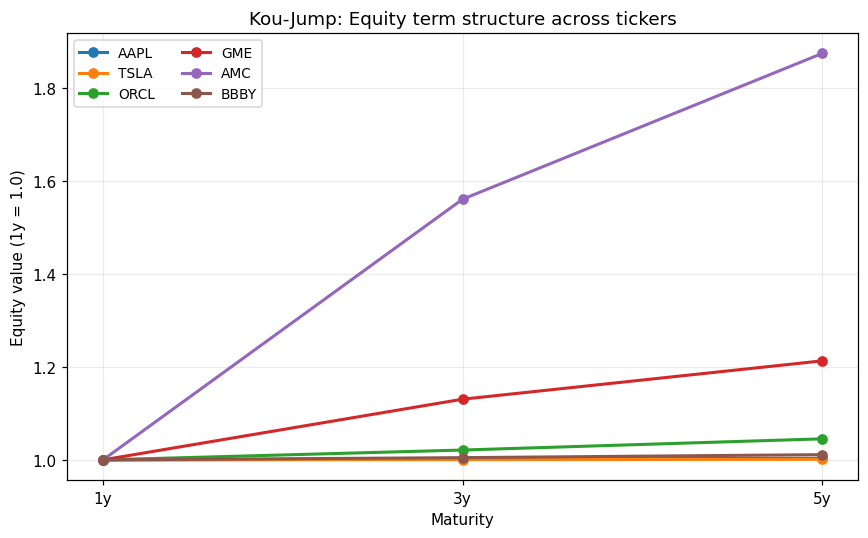

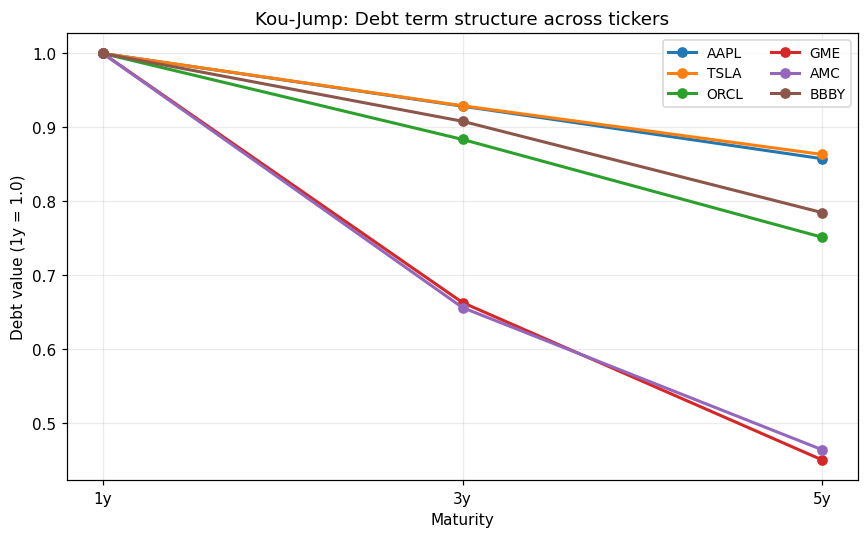

In [8]:
CROSS_TICKER_MODELS = ["Heston", "Merton-Jump", "Kou-Jump"]


def _plot_cross_ticker(model: str, side: str, normalise: bool = True) -> None:
    plt.figure(figsize=(8, 5))
    model_df = long_prices.loc[long_prices["model"] == model]
    if model_df.empty:
        plt.close()
        return
    for ticker in inputs_by_ticker.keys():
        row = model_df.loc[model_df["ticker"] == ticker]
        if row.empty:
            continue
        values = np.array([float(row[f"{side}_{T}y"].iloc[0]) for T in MATURITIES])
        if normalise and values[0] != 0:
            values = values / values[0]
        plt.plot(MATURITY_LABELS, values, marker="o", linewidth=2, label=ticker)
    ylabel = f"{side.capitalize()} value (1y = 1.0)" if normalise else f"{side.capitalize()} value"
    plt.title(f"{model}: {side.capitalize()} term structure across tickers")
    plt.xlabel("Maturity")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


for model in CROSS_TICKER_MODELS:
    _plot_cross_ticker(model, "equity", normalise=True)
    _plot_cross_ticker(model, "debt", normalise=True)

## 7. Implied credit spreads

Given a model debt price $D$ and face value $F$, the model-implied yield is

$$y(T) = -\frac{1}{T} \ln \frac{D}{F},$$

so the credit spread relative to the risk-free rate is $s(T) = y(T) - r$.

Equivalently, $s(T) = -\frac{1}{T} \ln \frac{D}{F e^{-rT}}$ — this is what `credit_spread_table` computes.

In [9]:
face_value_by_ticker = {t: inp.total_debt for t, inp in inputs_by_ticker.items()}

# For CS (which uses a 2023 risk-free rate), use a per-ticker risk-free rate.
# We approximate by using an average risk-free rate across tickers - the spread
# table here reuses one rate; for individual analyses use ``inp.risk_free_rate``.
representative_r = float(np.mean([inp.risk_free_rate for inp in inputs_by_ticker.values()]))

spread_table = credit_spread_table(
    long_prices,
    risk_free_rate=representative_r,
    face_value_by_ticker=face_value_by_ticker,
    maturities=MATURITIES,
)
spread_table_bps = spread_table.copy()
for col in spread_table_bps.columns:
    if col.startswith("credit_spread_"):
        spread_table_bps[col] = spread_table_bps[col] * 1e4  # convert to bps
spread_table_bps

,ticker,model,credit_spread_1y,credit_spread_3y,credit_spread_5y
0,AAPL,BSM,0.0000,0.0487,1.5959
1,AAPL,Heston,-0.0000,0.4058,4.9552
2,AAPL,Merton-Jump,0.0000,0.0813,2.1773
3,AAPL,Kou-Jump,0.0147,2.1144,13.7112
4,TSLA,BSM,-0.0000,0.0000,0.0001
5,TSLA,Heston,-0.0000,-0.0000,-0.0000
6,TSLA,Merton-Jump,-0.0000,0.0000,0.0004
7,TSLA,Kou-Jump,-0.0017,0.0219,0.3176
8,ORCL,BSM,2.2516,79.4052,160.0264
9,ORCL,Heston,11.1291,106.4652,181.7508


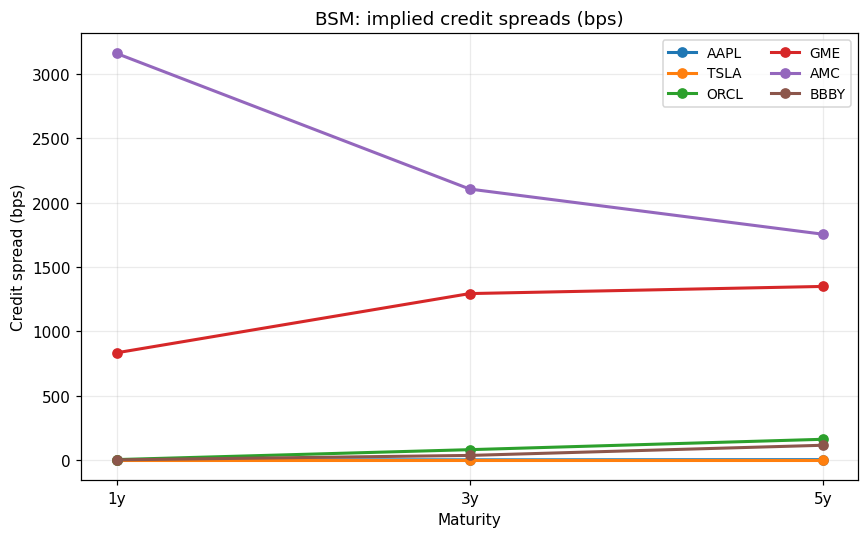

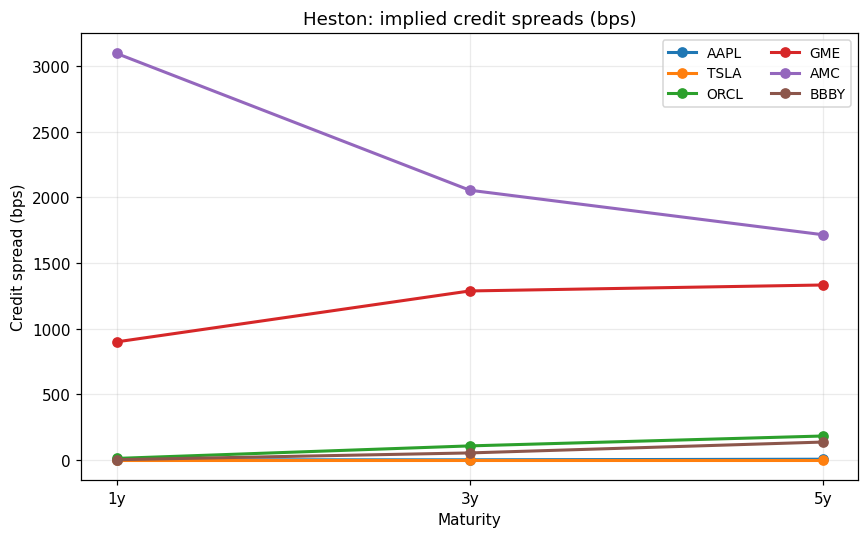

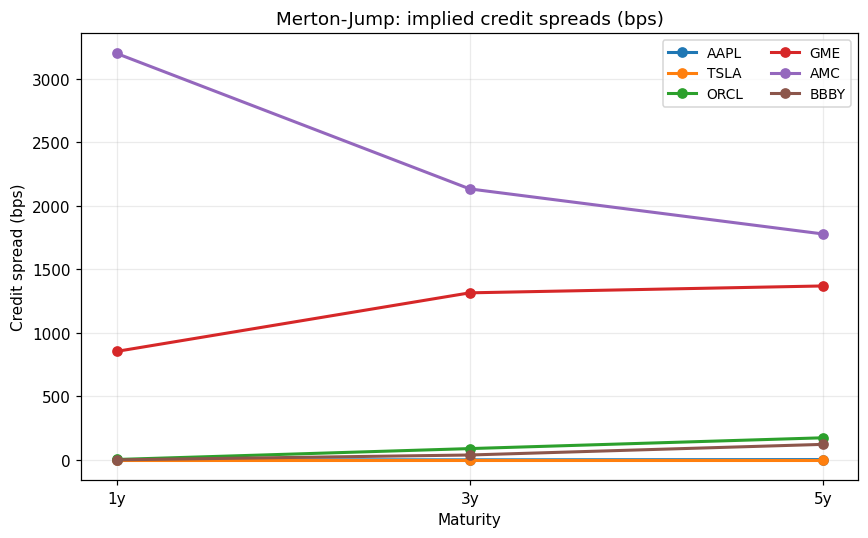

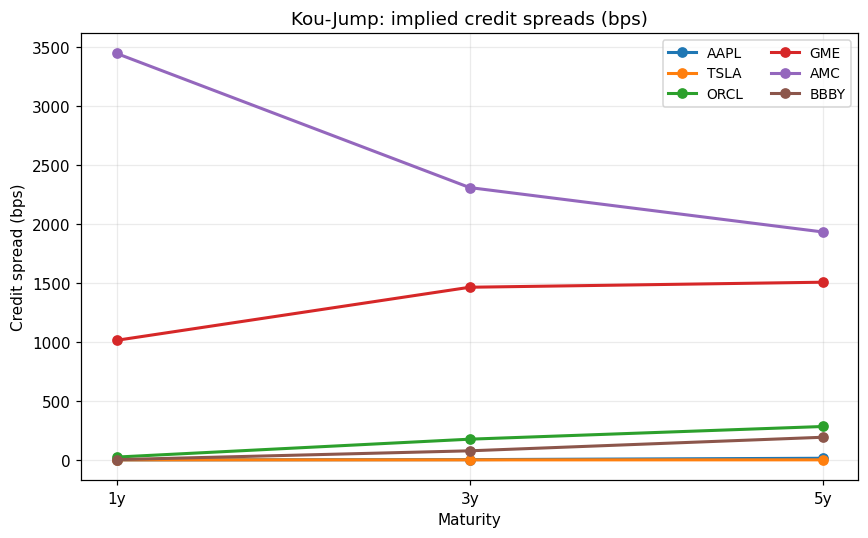

In [10]:
def _plot_spread_by_ticker(model: str) -> None:
    plt.figure(figsize=(8, 5))
    sub = spread_table_bps.loc[spread_table_bps["model"] == model]
    if sub.empty:
        plt.close()
        return
    for _, row in sub.iterrows():
        values = [float(row[f"credit_spread_{T}y"]) for T in MATURITIES]
        plt.plot(MATURITY_LABELS, values, marker="o", linewidth=2, label=row["ticker"])
    plt.title(f"{model}: implied credit spreads (bps)")
    plt.xlabel("Maturity")
    plt.ylabel("Credit spread (bps)")
    plt.grid(alpha=0.25)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


for model in MODEL_STYLE.keys():
    _plot_spread_by_ticker(model)

## 8. Discussion

Things to look for in the tables and plots above.

- **BSM vs Heston.** Stochastic volatility (Heston) typically produces fatter equity tails and slightly different equity values at long horizons, while affecting debt credit spreads — even with no jumps. The effect is modest for liquid investment-grade names (AAPL, ORCL, TSLA) but more pronounced for highly volatile distressed names (GME, AMC, BBBY).

- **BSM vs Merton-Jump.** Adding lognormal jumps with negative mean (`muJ = -0.05`) increases left-tail mass in asset returns. This raises the put value (through default risk) and therefore reduces the model debt price for a given face value, widening credit spreads — most visibly for distressed names where $A_0 / K$ is closer to 1 (especially BBBY with extreme leverage).

- **Merton-Jump vs Kou-Jump.** Kou's double-exponential jumps capture asymmetric tails (`p = 0.4` and `eta1 \ne eta2`) more flexibly than Merton's symmetric Gaussian jumps. For deeply distressed names (GME, BBBY) the Kou model tends to produce meaningfully different debt spreads, consistent with empirical evidence that real default risk has heavier downside tails than a Gaussian jump can capture.

- **Investment-grade vs Distressed.** Compare AAPL/ORCL/TSLA against GME/AMC/BBBY: 
  - IG companies have low leverage ($A_0/K \gg 1$), so all four models price debt nearly identically—they're far OTM.
  - Distressed companies have high leverage ($A_0/K$ close to 1), so jump models diverge sharply from BSM. BBBY in particular shows dramatic spread widening in jump models.

- **Maturity term structure.** Under Merton (1974), credit spreads are typically hump-shaped for low-leverage firms (short maturities show low spreads because default needs time; longer maturities benefit from drift and show smaller spreads again). Distressed high-leverage names like BBBY show monotonically elevated spreads across all maturities, reflecting near-term default risk.